<a href="https://colab.research.google.com/github/sinikar0397/Optimizing-Hypothesis-Space-via-Group-Representation-Intertwiner/blob/main/Equivariant_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 물리 시뮬레이션 제작(단일 궤적 예시)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 하이퍼파라미터
k = 1.0
dt = 0.01
epsilon = 0.5
EPOCH = 5000

In [3]:
# 상황 초기설정
m = np.array([10.0, 10.0, 20.0])
x = np.array([
    [1.0, 0.0],
    [-0.5, 0.86],
    [-0.5, -0.86]
])
v = np.array([
    [0.0, 1.0],
    [-3.4, 1.0],
    [1.7, -1.0]
])

In [ ]:
# 가속도 계산
def get_acceleration(x, m, k, epsilon):
    n = len(m)
    accel = np.zeros_like(x)
    for i in range(n):
        diff = x - x[i]
        dist_sq = np.sum(diff**2, axis=1) + epsilon**2
        dist_cubed = (dist_sq**1.5).reshape(-1, 1)

        force_i = k * (m.reshape(-1, 1) * diff / dist_cubed)
        accel[i] = force_i.sum(axis=0)
    return accel

In [ ]:
# 오일러 방법을 통해 물리 시뮬레이션 이용
history_x = []
history_v = []
for _ in range(EPOCH):
    a = get_acceleration(x, m, k, epsilon)
    v += a * dt
    x += v * dt
    history_x.append(x.copy())
    history_v.append(v.copy())

history_x = np.array(history_x)
history_v = np.array(history_v)

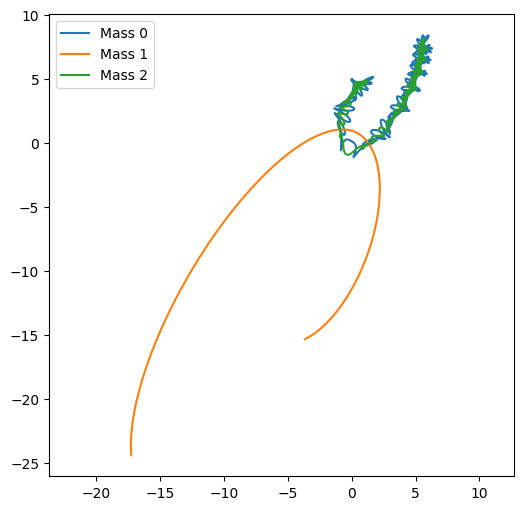

In [ ]:
# 실제 궤적 결과
plt.figure(figsize=(6,6))
for i in range(len(m)):
    plt.plot(history_x[:, i, 0], history_x[:, i, 1], label=f'Mass {i}')
plt.legend()
plt.axis('equal')
plt.show()

# 데이터 대량 생산

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.optim as optim
from tqdm.notebook import tqdm
import pytorch_model_summary

KeyboardInterrupt: 

In [ ]:


def get_acceleration(x, m, k, epsilon):
    n = len(m)
    accel = np.zeros_like(x)
    for i in range(n):
        diff = x - x[i]
        dist_sq = np.sum(diff**2, axis=1) + epsilon**2
        dist_cubed = (dist_sq**1.5).reshape(-1, 1)

        force_i = k * (m.reshape(-1, 1) * diff / dist_cubed)
        accel[i] = force_i.sum(axis=0)
    return accel

#데이터 대량 생산
def generate_dataset(num_trajectories=10, steps_per_traj=1000):
    all_X, all_Y = [], []
    m = np.array([10.0, 10.0, 20.0]) # 입자 1, 2는 동일 질량 (대칭)
    dt = 0.01

    for _ in tqdm(range(num_trajectories), desc = 'each trajectories'):
        x = np.random.randn(3, 2)
        v = np.random.randn(3, 2)
        v -= v.mean(axis = 0)

        traj = []
        for _ in tqdm(range(steps_per_traj), desc = 'particle moving...', leave = False):
            current_state = np.concatenate([x.flatten(), v.flatten()])
            traj.append(current_state)

            a = get_acceleration(x, m, 1.0, 0.5)
            v += a * dt
            x += v * dt

        traj = np.array(traj)
        all_X.append(traj[:-10:10]) # Input: t
        all_Y.append(traj[10::10])  # Target: t+10*dt

    return torch.FloatTensor(np.concatenate(all_X)), torch.FloatTensor(np.concatenate(all_Y))

X_train, Y_train = generate_dataset(num_trajectories = 400, steps_per_traj = 5000)
X_test, Y_test   = generate_dataset(num_trajectories = 50 , steps_per_traj = 5000)


each trajectories:   0%|          | 0/400 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

...

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

particle moving...:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
torch.save(X_train, './data/X_train.pt')
torch.save(X_test,  './data/X_test.pt')
torch.save(Y_train, './data/Y_train.pt')
torch.save(Y_test,  './data/Y_test.pt')

mkdir: cannot create directory ‘data’: File exists


In [37]:
device = torch.device('mps' if torch.backends.mps.is_available() and torch.backends.mps.is_built() else 'cpu')
X_train = torch.load('./data/X_train.pt', map_location = device)
X_test = torch.load('./data/X_test.pt', map_location = device)
Y_train = torch.load('./data/Y_train.pt', map_location = device)
Y_test = torch.load('./data/Y_test.pt', map_location = device)

# 모델 정의(객체 정의)

In [11]:
class EquivariantLinear2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_c = in_channels
        self.out_c = out_channels

        scale = 1.0 / np.sqrt(in_channels * 3)

        self.A = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.B = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.C = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.D = nn.Parameter(torch.randn(out_channels, in_channels) * scale)
        self.E = nn.Parameter(torch.randn(out_channels, in_channels) * scale)

        self.bias_sym = nn.Parameter(torch.zeros(out_channels))
        self.bias_third = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        row1 = torch.cat([self.A, self.B, self.C], dim=1)
        row2 = torch.cat([self.B, self.A, self.C], dim=1)
        row3 = torch.cat([self.D, self.D, self.E], dim=1)
        W = torch.cat([row1, row2, row3], dim=0)   # (3*out_c, 3*in_c)

        b = torch.cat([self.bias_sym, self.bias_sym, self.bias_third], dim=0)
        return x @ W.t() + b

class EquivariantModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            EquivariantLinear2D(4, 16),
            nn.ReLU(),
            EquivariantLinear2D(16, 16),
            nn.ReLU(),
            EquivariantLinear2D(16, 4)
        )

    def forward(self, x):
        return self.net(x)
# 실제 모델 학습
def train(model, X, Y, epochs=1000):
    train_log = []
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    bar = tqdm(range(epochs), desc = 'training')
    for epoch in bar:
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, Y)
        loss.backward()
        optimizer.step()
        bar.set_description(f'loss : {loss.item():.6f}')
        train_log.append(loss.item())
    return train_log

# 모델 평가
def check_symmetry(model, sample_input):
    out1 = model(sample_input)
    permuted_input = sample_input.clone()
    permuted_input[0:4], permuted_input[4:8] = sample_input[4:8], sample_input[0:4]

    out2 = model(permuted_input)
    out2_swapped = out2.clone()
    out2_swapped[0:4], out2_swapped[4:8] = out2[4:8], out2[0:4]

    symmetry_error = torch.abs(out1 - out2_swapped).mean().item()
    return symmetry_error

def evaluate_model(name, model, X_test, Y_test):
    model.eval()
    with torch.no_grad():
        pred = model(X_test)
        test_loss = nn.MSELoss()(pred, Y_test).item()
        sym_error = check_symmetry(model, X_test[0])

    print(f"[{name} 결과]")
    print(f" - Test Loss (일반화 오차): {test_loss:.6f}")
    print(f" - Symmetry Error (물리적 일관성): {sym_error:.10e}")
    return test_loss

def display_log(history1, history2, name1, name2):
    size = len(history1)
    plt.figure(figsize = (10, 6))
    plt.plot(np.arange(1, size + 1), history1, label = name1)
    plt.plot(np.arange(1, size + 1), history2, label = name2)
    plt.legend()
    plt.grid()
    plt.show()

## model 1
(12 -> 48 -> 48 ->12)

In [46]:
vanilla_model1 = nn.Sequential(
    nn.Linear(12, 48),
    nn.ReLU(),
    nn.Linear(48, 48),
    nn.ReLU(),
    nn.Linear(48, 12)
)

equiv_model1 = nn.Sequential(
    EquivariantLinear2D(4, 16),
    nn.ReLU(),
    EquivariantLinear2D(16, 16),
    nn.ReLU(),
    EquivariantLinear2D(16, 4)
)

vanilla_model1.to(device)
equiv_model1.to(device)

'.'

'.'

In [47]:
print('\n\nvanila model1')
print(pytorch_model_summary.summary(vanilla_model1, torch.zeros(12, device = device)))

print('\n\nequiv model1')
print(pytorch_model_summary.summary(equiv_model1, torch.zeros(12, device = device)))



vanila model1
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1                [48]             624             624
            ReLU-2                [48]               0               0
          Linear-3                [48]           2,352           2,352
            ReLU-4                [48]               0               0
          Linear-5                [12]             588             588
Total params: 3,564
Trainable params: 3,564
Non-trainable params: 0
-----------------------------------------------------------------------


equiv model1
-----------------------------------------------------------------------------
            Layer (type)        Output Shape         Param #     Tr. Param #
   EquivariantLinear2D-1                [48]             352             352
                  ReLU-2                [48]               0               0
   EquivariantLinear2D

In [48]:
print("--- Vanilla MLP 학습 ---")
valina_log1 = train(vanilla_model1, X_train, Y_train, 400)
print("\n--- Equivariant MLP 학습 ---")
equiv_log1  = train(equiv_model1,   X_train, Y_train, 400)

--- Vanilla MLP 학습 ---


training:   0%|          | 0/400 [00:00<?, ?it/s]


--- Equivariant MLP 학습 ---


training:   0%|          | 0/400 [00:00<?, ?it/s]

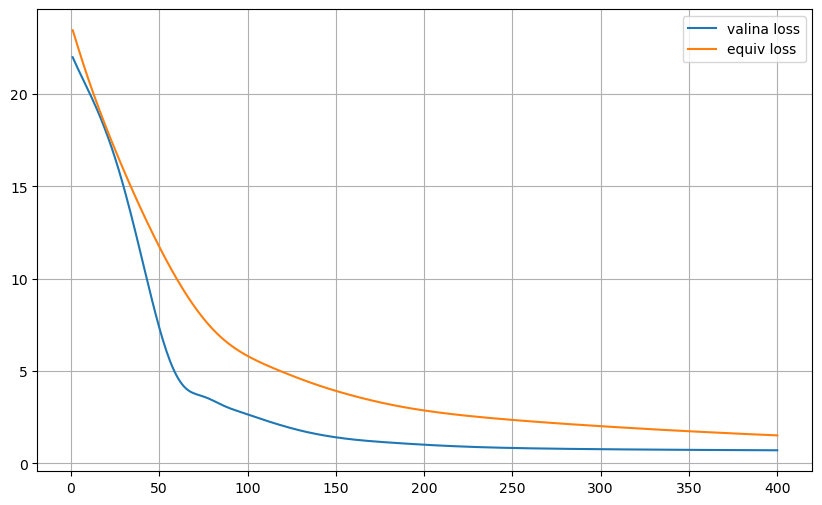

In [49]:
display_log(valina_log1, equiv_log1, 'valina loss', 'equiv loss')

In [50]:
evaluate_model("Vanilla MLP",     vanilla_model1, X_test, Y_test)
evaluate_model("Equivariant MLP", equiv_model1,   X_test, Y_test)

[Vanilla MLP 결과]
 - Test Loss (일반화 오차): 0.725704
 - Symmetry Error (물리적 일관성): 2.5664535165e-01
[Equivariant MLP 결과]
 - Test Loss (일반화 오차): 1.984676
 - Symmetry Error (물리적 일관성): 0.0000000000e+00


1.9846760034561157

In [51]:
import pickle

torch.save(equiv_model1.state_dict(), './models/equiv_model1_0408.pt')
torch.save(vanilla_model1.state_dict(), './models/vanilla_model1_0408.pt')

with open('./logs/equiv_log1_0408.pkl', 'wb') as f:
    pickle.dump(equiv_log1, f)
with open('./logs/vanilla_log1_0408.pkl', 'wb') as f:
    pickle.dump(valina_log1, f)

## model2
(12 -> 48 -> 96 -> 96 -> 48 -> 12)

In [56]:
vanilla_model2 = nn.Sequential(
    nn.Linear(12, 48),
    nn.ReLU(),
    nn.Linear(48, 96),
    nn.ReLU(),
    nn.Linear(96, 96),
    nn.ReLU(),
    nn.Linear(96, 48),
    nn.ReLU(),
    nn.Linear(48, 12)
)

equiv_model2 = nn.Sequential(
    EquivariantLinear2D(4, 16),
    nn.ReLU(),
    EquivariantLinear2D(16, 24),
    nn.ReLU(),
    EquivariantLinear2D(24, 24),
    nn.ReLU(),
    EquivariantLinear2D(24, 16),
    nn.ReLU(),
    EquivariantLinear2D(16, 4)
)

vanilla_model2.to(device)
equiv_model2.to(device)

'.'

'.'

In [57]:
print('\n\nvanila model1')
print(pytorch_model_summary.summary(vanilla_model2, torch.zeros(12, device = device)))

print('\n\nequiv model1')
print(pytorch_model_summary.summary(equiv_model2, torch.zeros(12, device = device)))



vanila model1
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1                [48]             624             624
            ReLU-2                [48]               0               0
          Linear-3                [96]           4,704           4,704
            ReLU-4                [96]               0               0
          Linear-5                [96]           9,312           9,312
            ReLU-6                [96]               0               0
          Linear-7                [48]           4,656           4,656
            ReLU-8                [48]               0               0
          Linear-9                [12]             588             588
Total params: 19,884
Trainable params: 19,884
Non-trainable params: 0
-----------------------------------------------------------------------


equiv model1
---------------------------------------------

In [67]:
print("--- Vanilla MLP 학습 ---")
vanilla_log2 = train(vanilla_model2, X_train, Y_train, 400)
print("\n--- Equivariant MLP 학습 ---")
equiv_log2  = train(equiv_model2,   X_train, Y_train, 400)

--- Vanilla MLP 학습 ---


training:   0%|          | 0/400 [00:00<?, ?it/s]


--- Equivariant MLP 학습 ---


training:   0%|          | 0/400 [00:00<?, ?it/s]

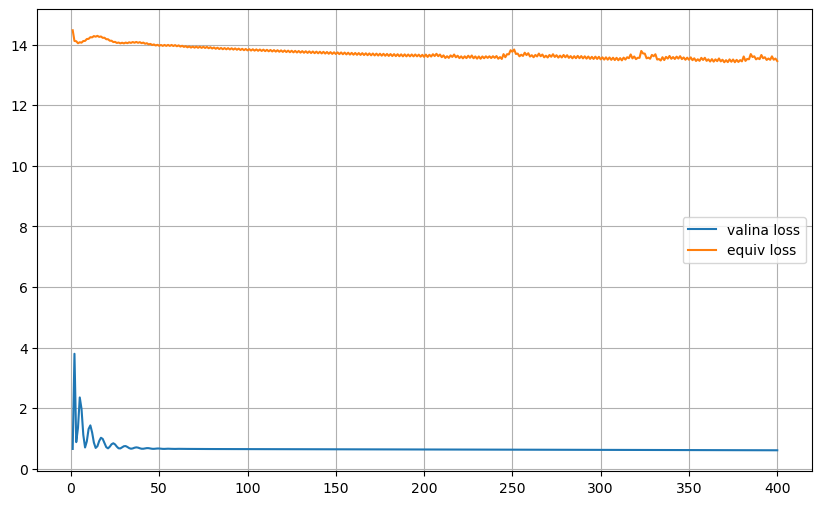

In [68]:
display_log(vanilla_log2, equiv_log2, 'valina loss', 'equiv loss')

In [70]:
evaluate_model("Vanilla MLP",     vanilla_model2, X_test, Y_test)
evaluate_model("Equivariant MLP", equiv_model2,   X_test, Y_test)

[Vanilla MLP 결과]
 - Test Loss (일반화 오차): 0.640400
 - Symmetry Error (물리적 일관성): 2.4453841150e-01
[Equivariant MLP 결과]
 - Test Loss (일반화 오차): 15.406775
 - Symmetry Error (물리적 일관성): 0.0000000000e+00


15.40677547454834

In [71]:
import pickle

torch.save(equiv_model1.state_dict(), './models/equiv_model2_0408.pt')
torch.save(vanilla_model1.state_dict(), './models/vanilla_model2_0408.pt')

with open('./logs/equiv_log2_0408.pkl', 'wb') as f:
    pickle.dump(equiv_log2, f)
with open('./logs/vanilla_log2_0408.pkl', 'wb') as f:
    pickle.dump(vanilla_log2, f)

## model3
(12 -> 96 -> 192 -> 48 -> 12)

In [72]:
vanilla_model3 = nn.Sequential(
    nn.Linear(12, 96),
    nn.ReLU(),
    nn.Linear(96, 192),
    nn.ReLU(),
    nn.Linear(192, 48),
    nn.ReLU(),
    nn.Linear(48, 12)
)

equiv_model3 = nn.Sequential(
    EquivariantLinear2D(4, 32),
    nn.ReLU(),
    EquivariantLinear2D(32, 64),
    nn.ReLU(),
    EquivariantLinear2D(64, 16),
    nn.ReLU(),
    EquivariantLinear2D(16, 4)
)

vanilla_model3.to(device)
equiv_model3.to(device)

'.'

'.'

In [73]:
print('\n\nvanila model3')
print(pytorch_model_summary.summary(vanilla_model3, torch.zeros(12, device = device)))

print('\n\nequiv model3')
print(pytorch_model_summary.summary(equiv_model3, torch.zeros(12, device = device)))



vanila model3
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1                [96]           1,248           1,248
            ReLU-2                [96]               0               0
          Linear-3               [192]          18,624          18,624
            ReLU-4               [192]               0               0
          Linear-5                [48]           9,264           9,264
            ReLU-6                [48]               0               0
          Linear-7                [12]             588             588
Total params: 29,724
Trainable params: 29,724
Non-trainable params: 0
-----------------------------------------------------------------------


equiv model3
-----------------------------------------------------------------------------
            Layer (type)        Output Shape         Param #     Tr. Param #
   EquivariantLinear2D-1        

In [74]:
print("--- Vanilla MLP 학습 ---")
vanilla_log3 = train(vanilla_model3, X_train, Y_train, 400)
print("\n--- Equivariant MLP 학습 ---")
equiv_log3  = train(equiv_model3,   X_train, Y_train, 400)

--- Vanilla MLP 학습 ---


training:   0%|          | 0/400 [00:00<?, ?it/s]


--- Equivariant MLP 학습 ---


training:   0%|          | 0/400 [00:00<?, ?it/s]

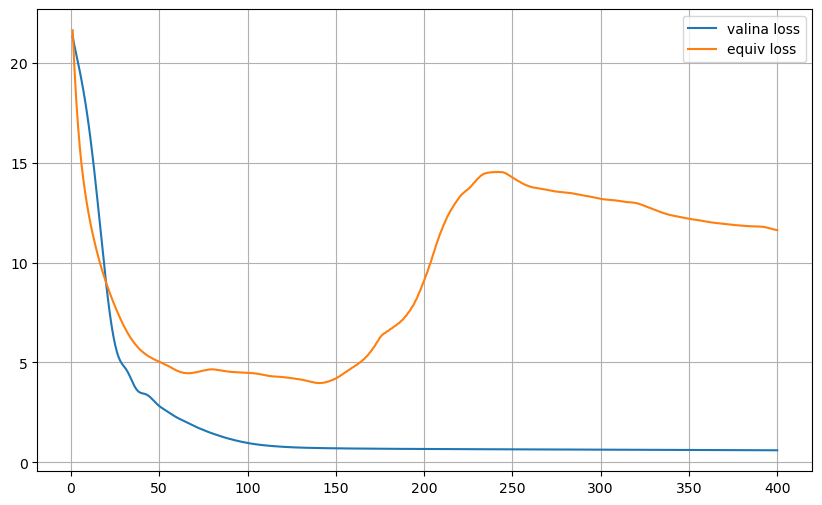

In [76]:
display_log(vanilla_log3, equiv_log3, 'valina loss', 'equiv loss')

In [ ]:
evaluate_model("Vanilla MLP",     vanilla_model2, X_test, Y_test)
evaluate_model("Equivariant MLP", equiv_model2,   X_test, Y_test)

[Vanilla MLP 결과]
 - Test Loss (일반화 오차): 0.684691
 - Symmetry Error (물리적 일관성): 1.5824463964e-01
[Equivariant MLP 결과]
 - Test Loss (일반화 오차): 0.814443
 - Symmetry Error (물리적 일관성): 1.8626451492e-07


0.8144434690475464

In [ ]:
!mkdir models
!mkdir logs
import pickle

torch.save(equiv_model1.state_dict(), './models/equiv_model2.pt')
torch.save(vanilla_model1.state_dict(), './models/vanilla_model2.pt')

with open('./logs/equiv_log2.pkl', 'wb') as f:
    pickle.dump(equiv_log2, f)
with open('./logs/vanilla_log2.pkl', 'wb') as f:
    pickle.dump(vanilla_log2, f)

mkdir: cannot create directory ‘models’: File exists
mkdir: cannot create directory ‘logs’: File exists
